<a href="https://colab.research.google.com/github/Argus-a/proj2/blob/main/robert_2_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import os
from transformers import AutoConfig

model_dir = '/content/drive/MyDrive/robert 2-7/'

if not os.path.exists(model_dir):
    print(f"Error: Directory not found at {model_dir}")
else:
    try:
        config = AutoConfig.from_pretrained(model_dir)

        if hasattr(config, 'id2label') and config.id2label:
            print("Labels (id2label mapping):")
            for label_id, label_name in config.id2label.items():
                print(f"  ID {label_id}: {label_name}")
        else:
            print("No 'id2label' mapping found in the configuration.")
            print("Full configuration object:")
            print(config)

    except Exception as e:
        print(f"Error loading configuration: {e}")
        print("Please ensure 'transformers' library is installed and the directory contains a valid config.json.")

KeyboardInterrupt: 

In [ ]:
from google.colab import files
import os

if not os.path.exists('kaggle.json'):
    print("الرجاء رفع ملف kaggle.json:")
    uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

الرجاء رفع ملف kaggle.json:


Saving twitter-emotion-classification-dataset[1].htm to twitter-emotion-classification-dataset[1].htm
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:

!kaggle datasets download -d aadyasingh55/twitter-emotion-classification-dataset

!unzip -o twitter-emotion-classification-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/aadyasingh55/twitter-emotion-classification-dataset
License(s): other
twitter-emotion-classification-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  twitter-emotion-classification-dataset.zip
  inflating: train-00000-of-00001.parquet  


In [ ]:
import pandas as pd
import glob

parquet_files = glob.glob("*.parquet")

if parquet_files:

    dataset_path = parquet_files[0]
    print(f"تم العثور على الملف: {dataset_path}")

    df = pd.read_parquet(dataset_path)
    display(df.head(5))
else:
    print("لم يتم العثور على ملفات Parquet بعد فك الضغط.")

تم العثور على الملف: train-00000-of-00001.parquet


,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2


Label Counts:


,count
label,
1,141067
0,121187
3,57317
4,47712
2,34554
5,14972


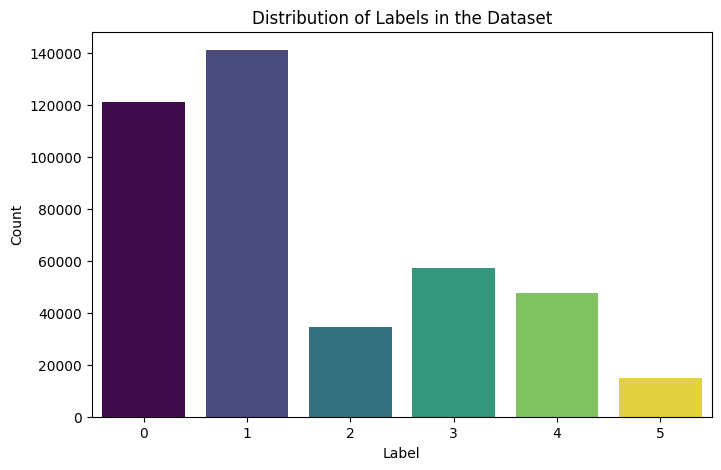

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


label_counts = df['label'].value_counts()
print("Label Counts:")
display(label_counts)


plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', hue='label', palette='viridis', legend=False)
plt.title('Distribution of Labels in the Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split


subset_size = min(200000, len(df))
df_subset = df.sample(n=subset_size, random_state=42)

train_df, val_df = train_test_split(
    df_subset,
    test_size=0.2,
    random_state=42,
    stratify=df_subset['label']
)

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

if '__index_level_0__' in train_dataset.column_names:
    train_dataset = train_dataset.remove_columns(['__index_level_0__'])
    val_dataset = val_dataset.remove_columns(['__index_level_0__'])

In [ ]:
from transformers import AutoTokenizer

model_dir = '/content/drive/MyDrive/robert 2-7/'
tokenizer = AutoTokenizer.from_pretrained(model_dir)

def tokenize_func(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

train_encoded = train_dataset.map(tokenize_func, batched=True)
val_encoded = val_dataset.map(tokenize_func, batched=True)

Map:   0%|          | 0/160000 [00:00<?, ? examples/s]

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

In [ ]:
import numpy as np
import evaluate

f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return f1_metric.compute(predictions=predictions, references=labels, average="weighted")

In [ ]:
from transformers import AutoModelForSequenceClassification

model_dir = '/content/drive/MyDrive/robert 2-7/'
num_labels = len(df['label'].unique())

model = AutoModelForSequenceClassification.from_pretrained(model_dir, num_labels=num_labels, ignore_mismatched_sizes=True)

[transformers] You passed `num_labels=6` which is incompatible to the `id2label` map of length `3`.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/robert 2-7/
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([6, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([6])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir='./emotion_model',
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_encoded,
    eval_dataset=val_encoded,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,0.091083,0.098807,0.939057
2,0.088276,0.094567,0.939758
3,0.086575,0.097774,0.942543


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.laye

TrainOutput(global_step=30000, training_loss=0.09883977394104004, metrics={'train_runtime': 13418.5438, 'train_samples_per_second': 35.771, 'train_steps_per_second': 2.236, 'total_flos': 3.157446057984e+16, 'train_loss': 0.09883977394104004, 'epoch': 3.0})

In [ ]:
import os

save_path = '/content/drive/MyDrive/robert 2-8'

os.makedirs(save_path, exist_ok=True)

print(f"Saving the best model and tokenizer to {save_path}...")

trainer.save_model(save_path)

tokenizer.save_pretrained(save_path)

print("Model and tokenizer saved successfully to Google Drive!")

Saving the best model and tokenizer to /content/drive/MyDrive/robert 2-8...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully to Google Drive!


In [ ]:
from transformers import pipeline

model_path = '/content/drive/MyDrive/robert 2-8'

print(f"Loading model from {model_path}...")
emotion_classifier = pipeline("text-classification", model=model_path, tokenizer=model_path)

test_texts = [
    "I feel so happy and joyful today!",
    "I am very sad and depressed about the news.",
    "This situation makes me incredibly angry!",
    "I am so scared of what might happen next.",
    "Wow, I am genuinely surprised by this amazing gift!"
]


print("\n--- Testing Model Predictions ---\n")
predictions = emotion_classifier(test_texts)


for text, pred in zip(test_texts, predictions):
    print(f"Text: '{text}'")
    print(f"Prediction: {pred['label']} (Confidence: {pred['score']:.4f})\n")

Loading model from /content/drive/MyDrive/robert 2-8...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- Testing Model Predictions ---

Text: 'I feel so happy and joyful today!'
Prediction: LABEL_1 (Confidence: 0.9999)

Text: 'I am very sad and depressed about the news.'
Prediction: LABEL_0 (Confidence: 0.9998)

Text: 'This situation makes me incredibly angry!'
Prediction: LABEL_3 (Confidence: 0.9999)

Text: 'I am so scared of what might happen next.'
Prediction: LABEL_4 (Confidence: 0.9997)

Text: 'Wow, I am genuinely surprised by this amazing gift!'
Prediction: LABEL_5 (Confidence: 0.9811)

